<cell_type>markdown</cell_type>## Overview

**Sensitivity analysis** helps you understand which layers in your model are:
- **Fragile** (sensitive): Large accuracy drop when compressed
- **Robust** (compressible): Minimal accuracy impact when compressed

This enables **non-uniform compression**: aggressive compression on robust layers, conservative on fragile ones.

The sensitivity module integrates with **fasterai** for:
- Using the same compression criteria (`large_final`, `movement`, etc.)
- True structural pruning via `Pruner`
- Consistent sparsity application via `Sparsifier`

This tutorial covers:
1. Basic sensitivity analysis
2. Different compression types (sparsity, pruning, quantization)
3. Analyzing and visualizing results
4. Generating non-uniform compression schedules
5. Multi-level sensitivity sweeps
6. Using different fasterai criteria

## Setup

In [ ]:
import torch
import torch.nn as nn
from torchvision.models import resnet18

from fasterbench import SensitivityAnalyzer, analyze_sensitivity
from fasterai.core.all import large_final, movement  # fasterai criteria

/home/nathan/miniconda3/envs/dev/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Prepare Model and Data

We'll use a pretrained ResNet-18 and CIFAR-10 for this tutorial.

In [ ]:
from fastai.vision.all import *
from fasterai.distill.all import *

model = resnet18()
path = untar_data(URLs.PETS)
files = get_image_files(path/"images")

def label_func(f): return f[0].isupper()

dls = ImageDataLoaders.from_name_func(path, files, label_func, item_tfms=Resize(64))
sample_input = torch.Tensor(dls.one_batch()[0][0][None]).cpu()

learn = vision_learner(dls, resnet18, metrics=accuracy)
learn.unfreeze()
learn.fit(3)

epoch,train_loss,valid_loss,accuracy,time
0,0.564845,0.427569,0.823410,00:02
1,0.355806,0.359399,0.843031,00:02
2,0.290419,0.397056,0.844384,00:02


### Define Evaluation Function

The key to using `SensitivityAnalyzer` is providing an evaluation function that:
- Takes a model as input
- Returns a single metric value (higher = better by default)

In [ ]:
def eval_accuracy(model, max_batches=20):
    """Compute accuracy on validation set."""
    model.eval()
    correct, total = 0, 0
    
    with torch.no_grad():
        for i, (x, y) in enumerate(dls.valid):
            if i >= max_batches:
                break
            outputs = model(x)
            correct += (outputs.argmax(1) == y).sum().item()
            total += len(y)
    
    return correct / total

# Test it
baseline = eval_accuracy(learn.model)
print(f"Baseline accuracy: {baseline:.4f}")

Baseline accuracy: 0.8453


```
Baseline accuracy: 0.8234
```

## 1. Basic Sensitivity Analysis

The simplest way to run sensitivity analysis:

In [ ]:
# One-liner: analyze sparsity sensitivity at 50%
result = analyze_sensitivity(learn.model, sample_input, eval_accuracy, "sparsity", level=50)

Computing baseline accuracy... 0.8453
Analyzing 22 layers for sparsity @ 50% (granularity=weight, criteria=abs)
  [1/22] 0.0... Δ=+0.0156
  [2/22] 0.4.0.conv1... Δ=+0.0016
  [3/22] 0.4.0.conv2... Δ=+0.0078
  [4/22] 0.4.1.conv1... Δ=+0.0102
  [5/22] 0.4.1.conv2... Δ=+0.0102
  [6/22] 0.5.0.conv1... Δ=-0.0133
  [7/22] 0.5.0.conv2... Δ=-0.0016
  [8/22] 0.5.0.downsample.0... Δ=+0.0102
  [9/22] 0.5.1.conv1... Δ=+0.0086
  [10/22] 0.5.1.conv2... Δ=+0.0078
  [11/22] 0.6.0.conv1... Δ=-0.0031
  [12/22] 0.6.0.conv2... Δ=-0.0031
  [13/22] 0.6.0.downsample.0... Δ=+0.0008
  [14/22] 0.6.1.conv1... Δ=-0.0031
  [15/22] 0.6.1.conv2... Δ=+0.0016
  [16/22] 0.7.0.conv1... Δ=0.0000
  [17/22] 0.7.0.conv2... Δ=-0.0008
  [18/22] 0.7.0.downsample.0... Δ=0.0000
  [19/22] 0.7.1.conv1... Δ=+0.0023
  [20/22] 0.7.1.conv2... Δ=+0.0016
  [21/22] 1.4... Δ=+0.0055
  [22/22] 1.8... Δ=0.0000
✓ Analysis complete


```
Computing baseline accuracy... 0.8234
Analyzing 21 layers for sparsity sensitivity @ 50%
  [1/21] conv1... Δ=+0.1523
  [2/21] layer1.0.conv1... Δ=+0.0892
  [3/21] layer1.0.conv2... Δ=+0.0156
  [4/21] layer1.1.conv1... Δ=+0.0078
  ...
  [21/21] fc... Δ=+0.0234
✓ Analysis complete
```

### View Results Summary

In [ ]:
result.summary()

════════════════════════════════════════════════════════════
Sensitivity Analysis: sparsity @ 50%
════════════════════════════════════════════════════════════
  Baseline accuracy: 0.8453
  Layers analyzed: 22

  🔴 Most Sensitive (fragile):
     1. 0.0                            Δ=+0.0156
     2. 0.4.1.conv1                    Δ=+0.0102
     3. 0.4.1.conv2                    Δ=+0.0102
     4. 0.5.0.downsample.0             Δ=+0.0102
     5. 0.5.1.conv1                    Δ=+0.0086

  🟢 Most Robust (compressible):
     1. 0.5.0.conv1                    Δ=-0.0133
     2. 0.6.0.conv1                    Δ=-0.0031
     3. 0.6.0.conv2                    Δ=-0.0031
     4. 0.6.1.conv1                    Δ=-0.0031
     5. 0.5.0.conv2                    Δ=-0.0016


```
════════════════════════════════════════════════════════════
Sensitivity Analysis: sparsity @ 50.0%
════════════════════════════════════════════════════════════
  Baseline accuracy: 0.8234
  Layers analyzed: 21

  🔴 Most Sensitive (fragile):
     1. conv1                          Δ=+0.1523
     2. layer1.0.conv1                 Δ=+0.0892
     3. layer2.0.conv1                 Δ=+0.0731
     4. layer2.0.conv2                 Δ=+0.0704
     5. layer2.1.conv2                 Δ=+0.0507

  🟢 Most Robust (compressible):
     1. layer3.0.downsample.0          Δ=-0.0108
     2. layer2.1.conv1                 Δ=-0.0054
     3. layer1.1.conv1                 Δ=+0.0061
     4. layer2.0.downsample.0          Δ=+0.0068
     5. layer3.1.conv2                 Δ=+0.0074
```

### Using the Full Analyzer Class

For more control, use `SensitivityAnalyzer` directly:

In [ ]:
analyzer = SensitivityAnalyzer(
    learn.model,
    sample_input,              # example input for Pruner dependency analysis
    eval_accuracy,
    criteria=large_final,      # fasterai criteria (magnitude-based)
    metric_name="accuracy",
    higher_is_better=True,     # accuracy: higher is better
)

result = analyzer.analyze(
    compression="sparsity",
    level=50,
    granularity="weight",      # unstructured sparsity
    verbose=True,
)

Computing baseline accuracy... 0.8453
Analyzing 22 layers for sparsity @ 50% (granularity=weight, criteria=abs)
  [1/22] 0.0... Δ=+0.0156
  [2/22] 0.4.0.conv1... Δ=+0.0016
  [3/22] 0.4.0.conv2... Δ=+0.0078
  [4/22] 0.4.1.conv1... Δ=+0.0102
  [5/22] 0.4.1.conv2... Δ=+0.0102
  [6/22] 0.5.0.conv1... Δ=-0.0133
  [7/22] 0.5.0.conv2... Δ=-0.0016
  [8/22] 0.5.0.downsample.0... Δ=+0.0102
  [9/22] 0.5.1.conv1... Δ=+0.0086
  [10/22] 0.5.1.conv2... Δ=+0.0078
  [11/22] 0.6.0.conv1... Δ=-0.0031
  [12/22] 0.6.0.conv2... Δ=-0.0031
  [13/22] 0.6.0.downsample.0... Δ=+0.0008
  [14/22] 0.6.1.conv1... Δ=-0.0031
  [15/22] 0.6.1.conv2... Δ=+0.0016
  [16/22] 0.7.0.conv1... Δ=0.0000
  [17/22] 0.7.0.conv2... Δ=-0.0008
  [18/22] 0.7.0.downsample.0... Δ=0.0000
  [19/22] 0.7.1.conv1... Δ=+0.0023
  [20/22] 0.7.1.conv2... Δ=+0.0016
  [21/22] 1.4... Δ=+0.0055
  [22/22] 1.8... Δ=0.0000
✓ Analysis complete


## 2. Different Compression Types

The analyzer supports three compression methods:

### Sparsity (Unstructured)

Zeros out individual weights by magnitude:

In [ ]:
result_sparsity = analyzer.analyze("sparsity", level=50, granularity="weight")

Computing baseline accuracy... 0.8453
Analyzing 22 layers for sparsity @ 50% (granularity=weight, criteria=abs)
  [1/22] 0.0... Δ=+0.0156
  [2/22] 0.4.0.conv1... Δ=+0.0016
  [3/22] 0.4.0.conv2... Δ=+0.0078
  [4/22] 0.4.1.conv1... Δ=+0.0102
  [5/22] 0.4.1.conv2... Δ=+0.0102
  [6/22] 0.5.0.conv1... Δ=-0.0133
  [7/22] 0.5.0.conv2... Δ=-0.0016
  [8/22] 0.5.0.downsample.0... Δ=+0.0102
  [9/22] 0.5.1.conv1... Δ=+0.0086
  [10/22] 0.5.1.conv2... Δ=+0.0078
  [11/22] 0.6.0.conv1... Δ=-0.0031
  [12/22] 0.6.0.conv2... Δ=-0.0031
  [13/22] 0.6.0.downsample.0... Δ=+0.0008
  [14/22] 0.6.1.conv1... Δ=-0.0031
  [15/22] 0.6.1.conv2... Δ=+0.0016
  [16/22] 0.7.0.conv1... Δ=0.0000
  [17/22] 0.7.0.conv2... Δ=-0.0008
  [18/22] 0.7.0.downsample.0... Δ=0.0000
  [19/22] 0.7.1.conv1... Δ=+0.0023
  [20/22] 0.7.1.conv2... Δ=+0.0016
  [21/22] 1.4... Δ=+0.0055
  [22/22] 1.8... Δ=0.0000
✓ Analysis complete


<cell_type>markdown</cell_type>### Pruning (Structural)

Uses fasterai's `Pruner` for true structural pruning - actually removes filters/channels:

In [ ]:
result_pruning = analyzer.analyze("pruning", level=30)

Computing baseline accuracy... 0.8453
Analyzing 22 layers for pruning @ 30% (structural, criteria=abs)
  [1/22] 0.0... Δ=0.0000
  [2/22] 0.4.0.conv1... Δ=+0.0266
  [3/22] 0.4.0.conv2... Δ=0.0000
  [4/22] 0.4.1.conv1... Δ=+0.0352
  [5/22] 0.4.1.conv2... Δ=0.0000
  [6/22] 0.5.0.conv1... Δ=+0.0031
  [7/22] 0.5.0.conv2... Δ=0.0000
  [8/22] 0.5.0.downsample.0... Δ=0.0000
  [9/22] 0.5.1.conv1... Δ=-0.0102
  [10/22] 0.5.1.conv2... Δ=0.0000
  [11/22] 0.6.0.conv1... Δ=-0.0258
  [12/22] 0.6.0.conv2... Δ=0.0000
  [13/22] 0.6.0.downsample.0... Δ=0.0000
  [14/22] 0.6.1.conv1... Δ=-0.0008
  [15/22] 0.6.1.conv2... Δ=0.0000
  [16/22] 0.7.0.conv1... Δ=+0.0062
  [17/22] 0.7.0.conv2... Δ=0.0000
  [18/22] 0.7.0.downsample.0... Δ=0.0000
  [19/22] 0.7.1.conv1... Δ=+0.0070
  [20/22] 0.7.1.conv2... Δ=0.0000
  [21/22] 1.4... Δ=+0.0023
  [22/22] 1.8... Δ=+0.1617
✓ Analysis complete


### Quantization

Simulates INT8 quantization per layer:

In [ ]:
result_quant = analyzer.analyze("quantization", level=8)  # 8-bit

Computing baseline accuracy... 0.8453
Analyzing 22 layers for quantization @ 8bits (per-channel, weights only)
  [1/22] 0.0... Δ=+0.0016
  [2/22] 0.4.0.conv1... Δ=+0.0031
  [3/22] 0.4.0.conv2... Δ=+0.0016
  [4/22] 0.4.1.conv1... Δ=+0.0008
  [5/22] 0.4.1.conv2... Δ=+0.0008
  [6/22] 0.5.0.conv1... Δ=0.0000
  [7/22] 0.5.0.conv2... Δ=+0.0008
  [8/22] 0.5.0.downsample.0... Δ=+0.0008
  [9/22] 0.5.1.conv1... Δ=0.0000
  [10/22] 0.5.1.conv2... Δ=0.0000
  [11/22] 0.6.0.conv1... Δ=0.0000
  [12/22] 0.6.0.conv2... Δ=+0.0008
  [13/22] 0.6.0.downsample.0... Δ=0.0000
  [14/22] 0.6.1.conv1... Δ=0.0000
  [15/22] 0.6.1.conv2... Δ=0.0000
  [16/22] 0.7.0.conv1... Δ=0.0000
  [17/22] 0.7.0.conv2... Δ=0.0000
  [18/22] 0.7.0.downsample.0... Δ=0.0000
  [19/22] 0.7.1.conv1... Δ=0.0000
  [20/22] 0.7.1.conv2... Δ=0.0000
  [21/22] 1.4... Δ=0.0000
  [22/22] 1.8... Δ=+0.0008
✓ Analysis complete


## 3. Analyzing Results

### Top Layers

In [ ]:
# Most sensitive (fragile) - should NOT compress aggressively
fragile = result.top(5, most_sensitive=True)
print("🔴 Fragile layers (protect these):")
for layer in fragile:
    print(f"   {layer.name}: Δ={layer.delta:+.4f}")

print()

# Most robust - CAN compress aggressively
robust = result.top(5, most_sensitive=False)
print("🟢 Robust layers (compress these):")
for layer in robust:
    print(f"   {layer.name}: Δ={layer.delta:+.4f}")

🔴 Fragile layers (protect these):
   0.0: Δ=+0.0156
   0.4.1.conv1: Δ=+0.0102
   0.4.1.conv2: Δ=+0.0102
   0.5.0.downsample.0: Δ=+0.0102
   0.5.1.conv1: Δ=+0.0086

🟢 Robust layers (compress these):
   0.5.0.conv1: Δ=-0.0133
   0.6.0.conv1: Δ=-0.0031
   0.6.0.conv2: Δ=-0.0031
   0.6.1.conv1: Δ=-0.0031
   0.5.0.conv2: Δ=-0.0016


```
🔴 Fragile layers (protect these):
   conv1: Δ=+0.1523
   layer1.0.conv1: Δ=+0.0892
   layer2.0.conv1: Δ=+0.0731
   layer2.0.conv2: Δ=+0.0704
   layer2.1.conv2: Δ=+0.0507

🟢 Robust layers (compress these):
   layer3.0.downsample.0: Δ=-0.0108
   layer2.1.conv1: Δ=-0.0054
   layer1.1.conv1: Δ=+0.0061
   layer2.0.downsample.0: Δ=+0.0068
   layer3.1.conv2: Δ=+0.0074
```

### Convert to DataFrame

In [ ]:
df = result.to_dataframe()
print(df[['name', 'layer_type', 'params', 'delta']].head(10))

                 name layer_type  params     delta
0                 0.0     Conv2d    9408  0.015625
1         0.4.0.conv1     Conv2d   36864  0.001563
2         0.4.0.conv2     Conv2d   36864  0.007812
3         0.4.1.conv1     Conv2d   36864  0.010156
4         0.4.1.conv2     Conv2d   36864  0.010156
5         0.5.0.conv1     Conv2d   73728 -0.013281
6         0.5.0.conv2     Conv2d  147456 -0.001563
7  0.5.0.downsample.0     Conv2d    8192  0.010156
8         0.5.1.conv1     Conv2d  147456  0.008594
9         0.5.1.conv2     Conv2d  147456  0.007812


```
                    name layer_type  params    delta
0                  conv1     Conv2d    9408   0.1523
1       layer1.0.conv1     Conv2d   36864   0.0892
2       layer1.0.conv2     Conv2d   36864   0.0156
3       layer1.1.conv1     Conv2d   36864   0.0061
4       layer1.1.conv2     Conv2d   36864   0.0217
5       layer2.0.conv1     Conv2d   73728   0.0731
6       layer2.0.conv2     Conv2d  147456   0.0704
7  layer2.0.downsample.0  Conv2d    8192   0.0068
8       layer2.1.conv1     Conv2d  147456  -0.0054
9       layer2.1.conv2     Conv2d  147456   0.0507
```

### Visualization

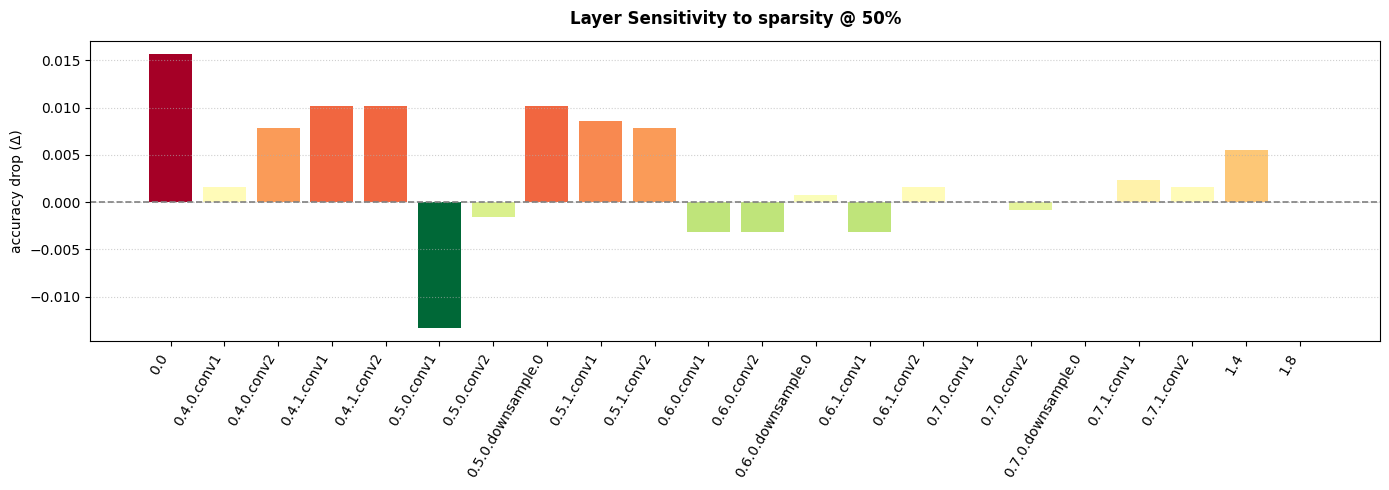

In [ ]:
result.plot(figsize=(14, 5))

This creates a bar chart with:
- **Red bars**: Sensitive layers (high accuracy drop)
- **Green bars**: Robust layers (low/negative accuracy drop)

![Sensitivity Plot](imgs/sensitivity_plot.png)

## 4. Non-Uniform Compression Schedules

The killer feature: convert sensitivity results into a per-layer compression schedule.

**Key insight**: Instead of applying 50% sparsity uniformly, we can:
- Apply 10-20% to fragile layers (protecting accuracy)
- Apply 70-90% to robust layers (maximizing compression)
- Still achieve 50% *overall* sparsity!

In [ ]:
schedule = result.to_schedule(
    learn.model,
    target_pct=50,    # Target 50% overall sparsity
    min_pct=5,        # No layer below 5%
    max_pct=90,       # No layer above 90%
    gamma=1.5,        # Higher = more differentiation
)

# View the schedule
print("Per-layer sparsity schedule:")
for name, sparsity in list(schedule.items())[:22]:
    print(f"  {name:30} {sparsity:5.1f}%")

Per-layer sparsity schedule:
  0.0                              5.0%
  0.4.0.conv1                     48.3%
  0.4.0.conv2                      5.8%
  0.4.1.conv1                      5.0%
  0.4.1.conv2                      5.0%
  0.5.0.conv1                     60.7%
  0.5.0.conv2                     60.7%
  0.5.0.downsample.0               5.0%
  0.5.1.conv1                      5.0%
  0.5.1.conv2                      5.8%
  0.6.0.conv1                     60.7%
  0.6.0.conv2                     60.7%
  0.6.0.downsample.0              54.4%
  0.6.1.conv1                     60.7%
  0.6.1.conv2                     48.3%
  0.7.0.conv1                     60.7%
  0.7.0.conv2                     60.7%
  0.7.0.downsample.0              60.7%
  0.7.1.conv1                     42.3%
  0.7.1.conv2                     48.3%
  1.4                             20.3%
  1.8                             60.7%


```
Per-layer sparsity schedule:
  conv1                          5.0%
  layer1.0.conv1                12.3%
  layer1.0.conv2                58.2%
  layer1.1.conv1                64.7%
  layer1.1.conv2                51.4%
  layer2.0.conv1                18.5%
  layer2.0.conv2                21.3%
  layer2.0.downsample.0         62.8%
  layer2.1.conv1                72.1%
  layer2.1.conv2                35.6%
```

### Using the Schedule with fasterai

The schedule can be directly passed to fasterai's `Sparsifier`:

In [ ]:
from fasterai.sparse.all import Sparsifier, large_final

# Convert schedule dict to list (in layer order)
sparsity_list = [schedule[name] for name in schedule.keys()]

# Apply non-uniform sparsity
sp = Sparsifier(learn.model, 'weight', 'local', large_final)
sp.sparsify_model(sparsity_list)

# Check results
sp.print_sparsity()


Sparsity Report:
--------------------------------------------------------------------------------
Layer                Type            Params     Zeros      Sparsity  
--------------------------------------------------------------------------------
Layer 2              Conv2d          9,408      471            5.01%
Layer 8              Conv2d          36,864     17,802        48.29%
Layer 11             Conv2d          36,864     2,127          5.77%
Layer 14             Conv2d          36,864     1,844          5.00%
Layer 17             Conv2d          36,864     1,844          5.00%
Layer 21             Conv2d          73,728     44,768        60.72%
Layer 24             Conv2d          147,456    89,535        60.72%
Layer 27             Conv2d          8,192      410            5.00%
Layer 30             Conv2d          147,456    7,373          5.00%
Layer 33             Conv2d          147,456    8,509          5.77%
Layer 37             Conv2d          294,912    179,070     

## 5. Multi-Level Sensitivity Sweep

Test sensitivity at multiple compression levels to understand how layers behave:

In [ ]:
# Sweep across multiple sparsity levels
results = analyzer.sweep(
    compression="sparsity",
    levels=[25, 50, 75, 90],
    verbose=True,
)


Sweep: sparsity @ 25%
Computing baseline accuracy... 0.8750
Analyzing 22 layers for sparsity @ 25% (granularity=weight, criteria=abs)
  [1/22] 0.0... Δ=+0.0016
  [2/22] 0.4.0.conv1... Δ=0.0000
  [3/22] 0.4.0.conv2... Δ=-0.0016
  [4/22] 0.4.1.conv1... Δ=+0.0023
  [5/22] 0.4.1.conv2... Δ=-0.0023
  [6/22] 0.5.0.conv1... Δ=0.0000
  [7/22] 0.5.0.conv2... Δ=0.0000
  [8/22] 0.5.0.downsample.0... Δ=0.0000
  [9/22] 0.5.1.conv1... Δ=+0.0023
  [10/22] 0.5.1.conv2... Δ=0.0000
  [11/22] 0.6.0.conv1... Δ=0.0000
  [12/22] 0.6.0.conv2... Δ=0.0000
  [13/22] 0.6.0.downsample.0... Δ=0.0000
  [14/22] 0.6.1.conv1... Δ=0.0000
  [15/22] 0.6.1.conv2... Δ=0.0000
  [16/22] 0.7.0.conv1... Δ=0.0000
  [17/22] 0.7.0.conv2... Δ=0.0000
  [18/22] 0.7.0.downsample.0... Δ=0.0000
  [19/22] 0.7.1.conv1... Δ=0.0000
  [20/22] 0.7.1.conv2... Δ=0.0000
  [21/22] 1.4... Δ=+0.0008
  [22/22] 1.8... Δ=+0.0039
✓ Analysis complete

Sweep: sparsity @ 50%
Computing baseline accuracy... 0.8750
Analyzing 22 layers for sparsity @ 50% (g

```
============================================================
Sweep: sparsity @ 25%
============================================================
Computing baseline accuracy... 0.8234
Analyzing 21 layers for sparsity sensitivity @ 25%
...
✓ Analysis complete

============================================================
Sweep: sparsity @ 50%
============================================================
...
```

In [ ]:
# Compare sensitivity at different levels
import pandas as pd

comparison = pd.DataFrame({
    f"{r.compression_level}%": {l.name: l.delta for l in r.layers}
    for r in results
})

print(comparison.head(10))

                         25%       50%       75%       90%
0.0                 0.001563  0.007031  0.042188  0.293750
0.4.0.conv1         0.000000  0.000781  0.053906  0.078125
0.4.0.conv2        -0.001563  0.001563  0.004687  0.021875
0.4.1.conv1         0.002344  0.005469  0.006250  0.015625
0.4.1.conv2        -0.002344  0.003125  0.029687  0.047656
0.5.0.conv1         0.000000  0.000000  0.010156  0.058594
0.5.0.conv2         0.000000  0.000000  0.009375  0.064844
0.5.0.downsample.0  0.000000  0.008594  0.015625  0.057031
0.5.1.conv1         0.002344 -0.000781  0.013281  0.092969
0.5.1.conv2         0.000000 -0.001563  0.007812  0.021094


```
                           25%     50%     75%     90%
conv1                   0.0412  0.1523  0.4521  0.7234
layer1.0.conv1          0.0234  0.0892  0.2341  0.5123
layer1.0.conv2          0.0045  0.0156  0.0678  0.2341
layer1.1.conv1          0.0012  0.0061  0.0234  0.1234
...
```

## 6. Using Loss as Metric

For loss metrics where lower is better:

In [ ]:
from fastai.losses import B

In [ ]:
def eval_loss(model, max_batches=20):
    """Compute average loss on validation set."""
    model.eval()
    criterion = CrossEntropyLossFlat()
    total_loss = 0
    
    with torch.no_grad():
        for i, (x, y) in enumerate(dls.valid):
            if i >= max_batches:
                break
            outputs = model(x)
            total_loss += criterion(outputs, y).item()
    
    return total_loss / max_batches

# Use higher_is_better=False for loss
analyzer_loss = SensitivityAnalyzer(
    learn.model,
    sample_input,              # example input required
    eval_loss,
    metric_name="loss",
    higher_is_better=False,    # Lower loss is better
)

result_loss = analyzer_loss.analyze("sparsity", level=50)

Computing baseline loss... 0.3087
Analyzing 22 layers for sparsity @ 50% (granularity=weight, criteria=abs)
  [1/22] 0.0... Δ=+0.0087
  [2/22] 0.4.0.conv1... Δ=-0.0008
  [3/22] 0.4.0.conv2... Δ=+0.0020
  [4/22] 0.4.1.conv1... Δ=+0.0072
  [5/22] 0.4.1.conv2... Δ=+0.0105
  [6/22] 0.5.0.conv1... Δ=0.0000
  [7/22] 0.5.0.conv2... Δ=0.0000
  [8/22] 0.5.0.downsample.0... Δ=+0.0097
  [9/22] 0.5.1.conv1... Δ=-0.0009
  [10/22] 0.5.1.conv2... Δ=+0.0033
  [11/22] 0.6.0.conv1... Δ=0.0000
  [12/22] 0.6.0.conv2... Δ=0.0000
  [13/22] 0.6.0.downsample.0... Δ=0.0000
  [14/22] 0.6.1.conv1... Δ=0.0000
  [15/22] 0.6.1.conv2... Δ=-0.0002
  [16/22] 0.7.0.conv1... Δ=0.0000
  [17/22] 0.7.0.conv2... Δ=0.0000
  [18/22] 0.7.0.downsample.0... Δ=0.0000
  [19/22] 0.7.1.conv1... Δ=+0.0005
  [20/22] 0.7.1.conv2... Δ=+0.0001
  [21/22] 1.4... Δ=+0.0036
  [22/22] 1.8... Δ=+0.0003
✓ Analysis complete


<cell_type>markdown</cell_type>## Summary

| Feature | Method | Description |
|---------|--------|-------------|
| **One-liner** | `analyze_sensitivity(model, sample, eval_fn)` | Quick sensitivity analysis |
| **Full analyzer** | `SensitivityAnalyzer(model, sample, eval_fn)` | Reusable analyzer with sweep support |
| **Compression types** | `"sparsity"`, `"pruning"`, `"quantization"` | Weight zeroing, structural pruning, INT8 |
| **Criteria** | `criteria=large_final` | fasterai criteria (`large_final`, `movement`, `random`) |
| **View results** | `result.summary()` | Formatted console output |
| **Top layers** | `result.top(n, most_sensitive=True/False)` | Most fragile or robust layers |
| **Visualization** | `result.plot()` | Bar chart with color coding |
| **DataFrame** | `result.to_dataframe()` | Export to pandas |
| **Schedule** | `result.to_schedule(model, target_pct=50)` | Non-uniform compression schedule |
| **Multi-level** | `analyzer.sweep(levels=[25, 50, 75])` | Test multiple compression levels |